In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
np.random.seed(0)

N = 120
x = np.linspace(-3, 3, N).reshape(-1, 1)
y_true = np.sin(x)

sigma_true = 0.2
y = y_true + np.random.normal(0, sigma_true, size=y_true.shape)

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from tqdm.notebook import tqdm

In [4]:
class DropoutBNN(nn.Module):
    def __init__(self, n_hidden, p_dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(1, n_hidden)
        self.dropout = nn.Dropout(p_dropout)
        self.fc2 = nn.Linear(n_hidden, 1)
    
    def forward(self, x):
        # Apply dropout during both training and test-time (MC Dropout)
        hidden = torch.tanh(self.fc1(x))
        hidden = self.dropout(hidden)  # stochastic layer
        mu = self.fc2(hidden)
        return mu

In [5]:
x_data = x.astype("float32")
y_data = y.flatten().astype("float32")

n_hidden = 20

In [6]:
model = DropoutBNN(n_hidden, p_dropout=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)#, weight_decay=1e-4)
criterion = nn.MSELoss()

# Convert your data to torch tensors
x_tensor = torch.tensor(x_data, dtype=torch.float32)
y_tensor = torch.tensor(y_data, dtype=torch.float32).view(-1, 1)

# Training loop
losses = []

model.train()
for epoch in tqdm(range(50_000)):
    optimizer.zero_grad()
    y_pred = model(x_tensor)
    loss = criterion(y_pred, y_tensor)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

  0%|          | 0/50000 [00:00<?, ?it/s]

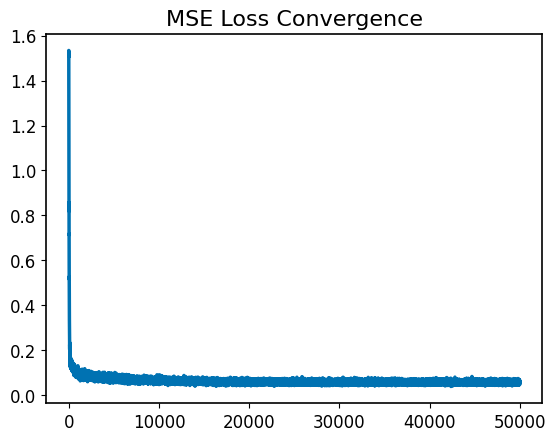

In [7]:
plt.plot(losses)
plt.title("MSE Loss Convergence")
plt.show()

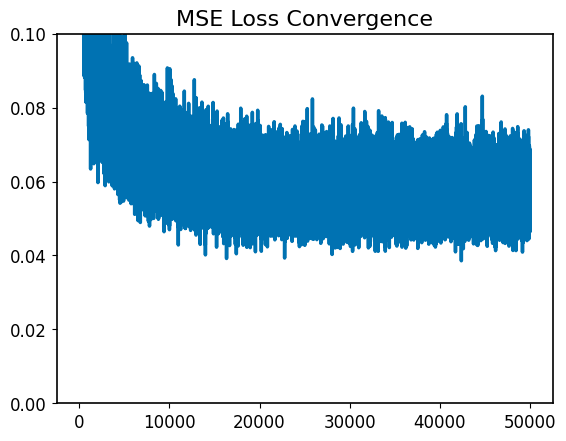

In [8]:
plt.plot(losses)
plt.title("MSE Loss Convergence")
plt.ylim(0, 0.1)
plt.show()

In [9]:
x_test = torch.linspace(-5, 5, 101).reshape(-1, 1)
y_test = torch.sin(x_test)

In [10]:
# Prediction with MC Dropout (approximate posterior)
model.train()
T = 2000  # number of MC samples
with torch.no_grad():
    predictions = torch.stack([model(x_test) for _ in range(T)])
pred_mean = predictions.mean(0).detach().numpy().flatten()
pred_std = predictions.std(0).detach().numpy().flatten()

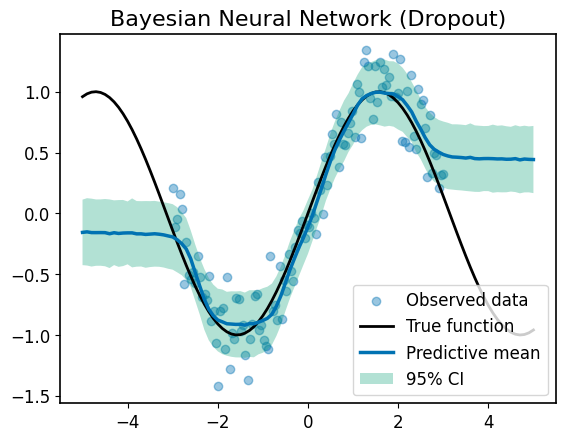

In [12]:
plt.scatter(x, y, alpha=0.4, label="Observed data")
plt.plot(x_test, y_test, color="black", linewidth=2, label="True function")

plt.plot(x_test, pred_mean, label="Predictive mean")
plt.fill_between(
    x_test.flatten(),
    pred_mean - 2*pred_std,
    pred_mean + 2*pred_std,
    alpha=0.3,
    label="95% CI"
)

plt.legend()
plt.title("Bayesian Neural Network (Dropout)")
plt.show()